<a href="https://colab.research.google.com/github/PardhuVarma55/ELECTRICAL-NETWORK-NATURAL-MODES/blob/main/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display

np.set_printoptions(precision=5, suppress=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# CELL 2: USER CONFIGURATION
# ============================================================

# -------- Inductors --------
# Units: Henry (H)

L1 = 100e-9       # 100 nH
L2 = 100e-9       # 100 nH
L3 = 100e-9       # 100 nH

# Mutual/shared inductive coupling
M12 = 20e-9       # 20 nH
M13 = 0e-9        # 0 nH
M23 = 20e-9       # 20 nH

# -------- Capacitors --------
# Units: Farad (F)

C1 = 10e-12       # 10 pF
C2 = 10e-12       # 10 pF
C3 = 10e-12       # 10 pF

# -------- Small resistance for resonance visualization --------
# This is NOT used when calculating ideal natural frequencies.
R1 = 0.5          # Ohm
R2 = 0.5
R3 = 0.5

# -------- Frequency sweep for resonance plot --------
f_min = 50e6      # 50 MHz
f_max = 280e6     # 280 MHz
number_of_points = 3000

# ============================================================
# Construct matrices
# ============================================================

L = np.array([
    [L1,  M12, M13],
    [M12, L2,  M23],
    [M13, M23, L3]
], dtype=float)

C = np.diag([C1, C2, C3])

R = np.diag([R1, R2, R3])

print("Inductance matrix L:")
print(L)

print("\nCapacitance matrix C:")
print(C)

print("\nResistance matrix R:")
print(R)

Inductance matrix L:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Capacitance matrix C:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Resistance matrix R:
[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0.5]]


In [ ]:
# ============================================================
# CELL 3: MODEL VALIDATION
# ============================================================

# Check symmetry
if not np.allclose(L, L.T):
    raise ValueError("Inductance matrix must be symmetric.")

# Check positive definiteness
L_eigenvalues = np.linalg.eigvalsh(L)

print("Eigenvalues of L:")
print(L_eigenvalues)

if np.all(L_eigenvalues > 0):
    print("\n✓ Inductance matrix is positive definite.")
    print("✓ Circuit model is physically suitable for the calculation.")
else:
    raise ValueError(
        "Inductance matrix is not positive definite. "
        "Reduce the mutual inductances."
    )

Eigenvalues of L:
[0. 0. 0.]

✓ Inductance matrix is positive definite.
✓ Circuit model is physically suitable for the calculation.


In [ ]:
# ============================================================
# CELL 4: MATHEMATICAL MODEL
# ============================================================

# Inverse capacitance matrix
C_inv = np.linalg.inv(C)

print("C⁻¹ matrix:")
print(C_inv)

print("\nNatural-mode differential equation:")
print("L · d²i/dt² + C⁻¹ · i = 0")

print("\nAssume:")
print("i(t) = v exp(jωt)")

print("\nTherefore:")
print("(C⁻¹ - ω²L)v = 0")

print("\nFor a non-zero eigenvector:")
print("det(C⁻¹ - ω²L) = 0")

# Convert to eigenvalue form
# λ = ω²
#
# C⁻¹ v = λ L v
#
# Multiplying by L⁻¹:
#
# L⁻¹ C⁻¹ v = λ v

A = np.linalg.solve(L, C_inv)

print("\nStandard eigenvalue matrix A = L⁻¹ C⁻¹:")
print(A)

C⁻¹ matrix:
[[1.e+11 0.e+00 0.e+00]
 [0.e+00 1.e+11 0.e+00]
 [0.e+00 0.e+00 1.e+11]]

Natural-mode differential equation:
L · d²i/dt² + C⁻¹ · i = 0

Assume:
i(t) = v exp(jωt)

Therefore:
(C⁻¹ - ω²L)v = 0

For a non-zero eigenvector:
det(C⁻¹ - ω²L) = 0

Standard eigenvalue matrix A = L⁻¹ C⁻¹:
[[ 1.04348e+18 -2.17391e+17  4.34783e+16]
 [-2.17391e+17  1.08696e+18 -2.17391e+17]
 [ 4.34783e+16 -2.17391e+17  1.04348e+18]]


In [ ]:
# ============================================================
# CELL 5: SYMBOLIC MATHEMATICAL FORM
# ============================================================

# Use normalized/scaled values for cleaner symbolic display.
# We scale L by nH and C by pF.

L_scaled = sp.Matrix([
    [L1/1e-9,  M12/1e-9, M13/1e-9],
    [M12/1e-9, L2/1e-9,  M23/1e-9],
    [M13/1e-9, M23/1e-9, L3/1e-9]
])

C_scaled = sp.diag(
    C1/1e-12,
    C2/1e-12,
    C3/1e-12
)

print("Inductance matrix in nH:")
display(L_scaled)

print("Capacitance matrix in pF:")
display(C_scaled)

# Symbolic eigenvalue variable
lam = sp.symbols('lambda')

# For demonstration:
# det(C⁻¹ - λL) = 0
#
# Using scaled matrices here gives the structure of the
# characteristic equation without huge SI numbers.

K_scaled = C_scaled.inv()

characteristic_matrix = K_scaled - lam * L_scaled

characteristic_equation = sp.factor(
    characteristic_matrix.det()
)

print("\nCharacteristic equation:")
display(sp.Eq(characteristic_equation, 0))

Inductance matrix in nH:


Matrix([
[100.0,  20.0,   0.0],
[ 20.0, 100.0,  20.0],
[  0.0,  20.0, 100.0]])

Capacitance matrix in pF:


Matrix([
[10.0,    0,    0],
[   0, 10.0,    0],
[   0,    0, 10.0]])


Characteristic equation:


Eq(-920000.0*(1.0*lambda**3 - 0.00317391304347826*lambda**2 + 3.26086956521739e-6*lambda - 1.08695652173913e-9), 0)

In [ ]:
# ============================================================
# CELL 6: EIGENVALUE / NATURAL FREQUENCY ENGINE
# ============================================================

# Solve:
#
# A v = λ v
#
# where:
#
# A = L⁻¹ C⁻¹
#
# λ = ω²

eigenvalues, eigenvectors = np.linalg.eig(A)

# Eigenvalues should be real for a valid passive model.
eigenvalues = np.real_if_close(eigenvalues).real

# Sort from lowest to highest frequency
order = np.argsort(eigenvalues)

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Angular natural frequencies
omega_n = np.sqrt(eigenvalues)

# Natural frequencies in Hz
frequency_hz = omega_n / (2 * np.pi)

# Normalize each eigenvector
# so the largest current magnitude in each mode is 1.
for k in range(eigenvectors.shape[1]):
    eigenvectors[:, k] /= np.max(np.abs(eigenvectors[:, k]))

# Fix arbitrary eigenvector sign for easier display.
for k in range(eigenvectors.shape[1]):
    max_index = np.argmax(np.abs(eigenvectors[:, k]))
    if eigenvectors[max_index, k] < 0:
        eigenvectors[:, k] *= -1

print("Natural-mode calculation completed.")

Natural-mode calculation completed.


In [ ]:
# ============================================================
# CELL 7: OUTPUT TABLE
# ============================================================

print("=" * 72)
print("        ELECTRICAL NETWORK NATURAL MODES")
print("=" * 72)

print("\nNatural frequencies:\n")

print(f"{'Mode':<8}{'Eigenvalue λ = ω²':<25}"
      f"{'ω (rad/s)':<20}{'f (MHz)':<15}")

print("-" * 72)

for k in range(3):
    print(
        f"{k+1:<8}"
        f"{eigenvalues[k]:<25.6e}"
        f"{omega_n[k]:<20.6e}"
        f"{frequency_hz[k]/1e6:<15.6f}"
    )

print("\n" + "=" * 72)
print("CURRENT DISTRIBUTION / EIGENVECTORS")
print("=" * 72)

print(
    f"\n{'Mode':<8}"
    f"{'I1':<15}"
    f"{'I2':<15}"
    f"{'I3':<15}"
)

print("-" * 55)

for k in range(3):
    print(
        f"{k+1:<8}"
        f"{eigenvectors[0,k]:<15.6f}"
        f"{eigenvectors[1,k]:<15.6f}"
        f"{eigenvectors[2,k]:<15.6f}"
    )

        ELECTRICAL NETWORK NATURAL MODES

Natural frequencies:

Mode    Eigenvalue λ = ω²        ω (rad/s)           f (MHz)        
------------------------------------------------------------------------
1       7.795188e+17             8.829036e+08        140.518474     
2       1.000000e+18             1.000000e+09        159.154943     
3       1.394394e+18             1.180845e+09        187.937274     

CURRENT DISTRIBUTION / EIGENVECTORS

Mode    I1             I2             I3             
-------------------------------------------------------
1       0.707107       1.000000       0.707107       
2       1.000000       0.000000       -1.000000      
3       -0.707107      1.000000       -0.707107      


In [ ]:
# ============================================================
# CELL 8: MODE INTERPRETATION
# ============================================================

print("=" * 72)
print("MODE INTERPRETATION")
print("=" * 72)

for k in range(3):

    mode = eigenvectors[:, k]

    print(f"\nMODE {k+1}")
    print("-" * 30)

    print(f"Natural frequency = {frequency_hz[k]/1e6:.3f} MHz")

    print(
        f"Current distribution: "
        f"[{mode[0]:+.3f}, {mode[1]:+.3f}, {mode[2]:+.3f}]"
    )

    if np.all(mode > 0) or np.all(mode < 0):
        print("Interpretation: currents are approximately in phase.")

    elif mode[1] * mode[0] < 0 and mode[1] * mode[2] < 0:
        print("Interpretation: the middle resonator is opposite in phase.")

    else:
        print("Interpretation: mixed phase relationship between resonators.")

MODE INTERPRETATION

MODE 1
------------------------------
Natural frequency = 140.518 MHz
Current distribution: [+0.707, +1.000, +0.707]
Interpretation: currents are approximately in phase.

MODE 2
------------------------------
Natural frequency = 159.155 MHz
Current distribution: [+1.000, +0.000, -1.000]
Interpretation: mixed phase relationship between resonators.

MODE 3
------------------------------
Natural frequency = 187.937 MHz
Current distribution: [-0.707, +1.000, -0.707]
Interpretation: the middle resonator is opposite in phase.


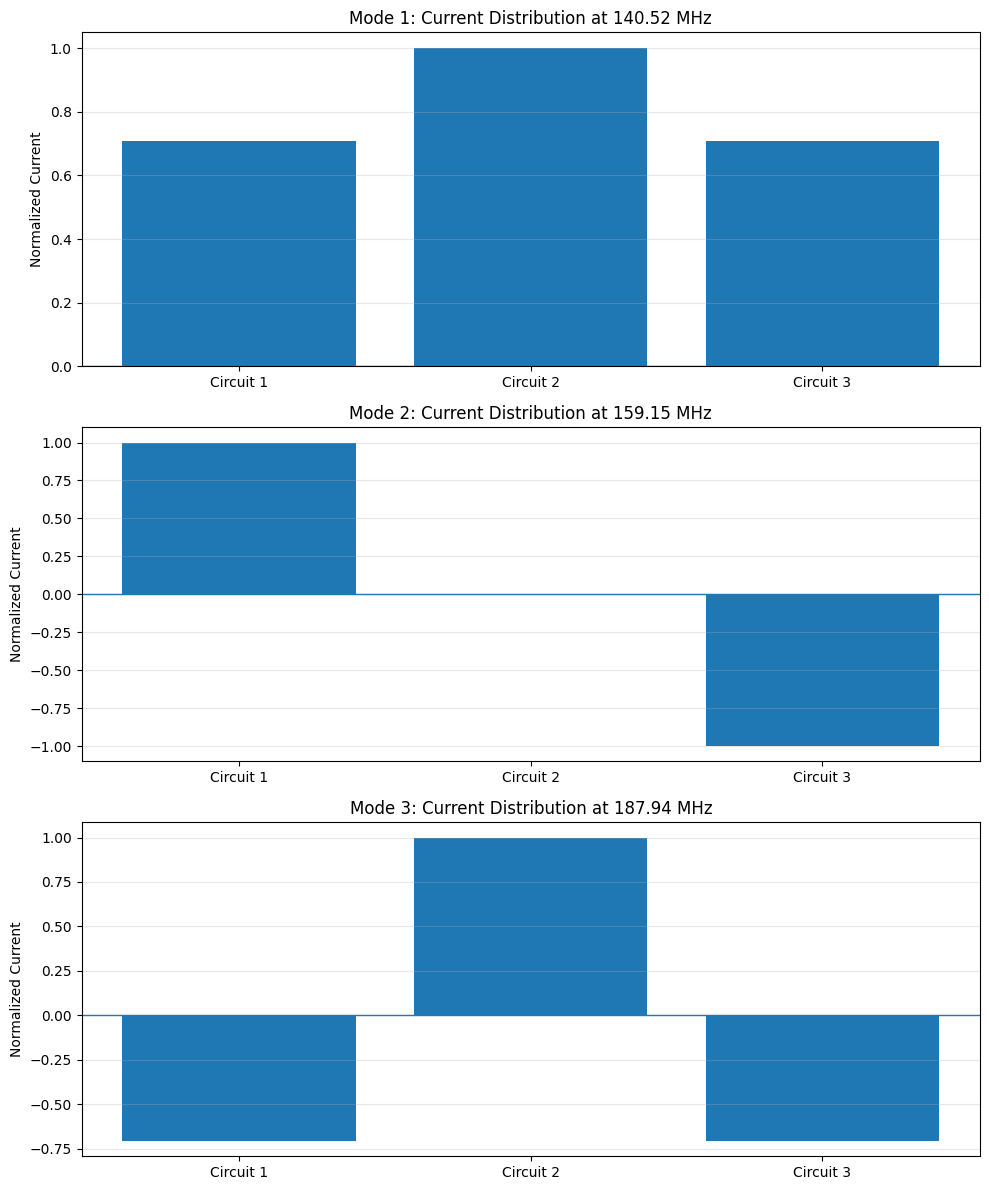

In [ ]:
# ============================================================
# CELL 9: EIGENVECTOR / CURRENT DISTRIBUTION CHART
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for k, ax in enumerate(axes):

    currents = eigenvectors[:, k]

    ax.bar(
        ["Circuit 1", "Circuit 2", "Circuit 3"],
        currents
    )

    ax.axhline(0, linewidth=1)

    ax.set_title(
        f"Mode {k+1}: Current Distribution "
        f"at {frequency_hz[k]/1e6:.2f} MHz"
    )

    ax.set_ylabel("Normalized Current")

    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10: RESONANCE / FREQUENCY RESPONSE
# ============================================================

frequencies = np.linspace(
    f_min,
    f_max,
    number_of_points
)

omega = 2 * np.pi * frequencies

# Apply a voltage excitation to circuit 1.
#
# This is simply a demonstration excitation:
#
# V = [1, 0, 0]^T

V_source = np.array([1.0, 0.0, 0.0])

current_magnitude = np.zeros_like(frequencies)

all_currents = np.zeros(
    (3, len(frequencies)),
    dtype=complex
)

for n, w in enumerate(omega):

    # Impedance matrix:
    #
    # Z = R + jωL + 1/(jω) C⁻¹

    Z = (
        R
        + 1j * w * L
        + C_inv / (1j * w)
    )

    # Solve ZI = V
    I = np.linalg.solve(Z, V_source)

    all_currents[:, n] = I

    # Total current magnitude
    current_magnitude[n] = np.linalg.norm(I)

print("Frequency-response calculation completed.")

Frequency-response calculation completed.


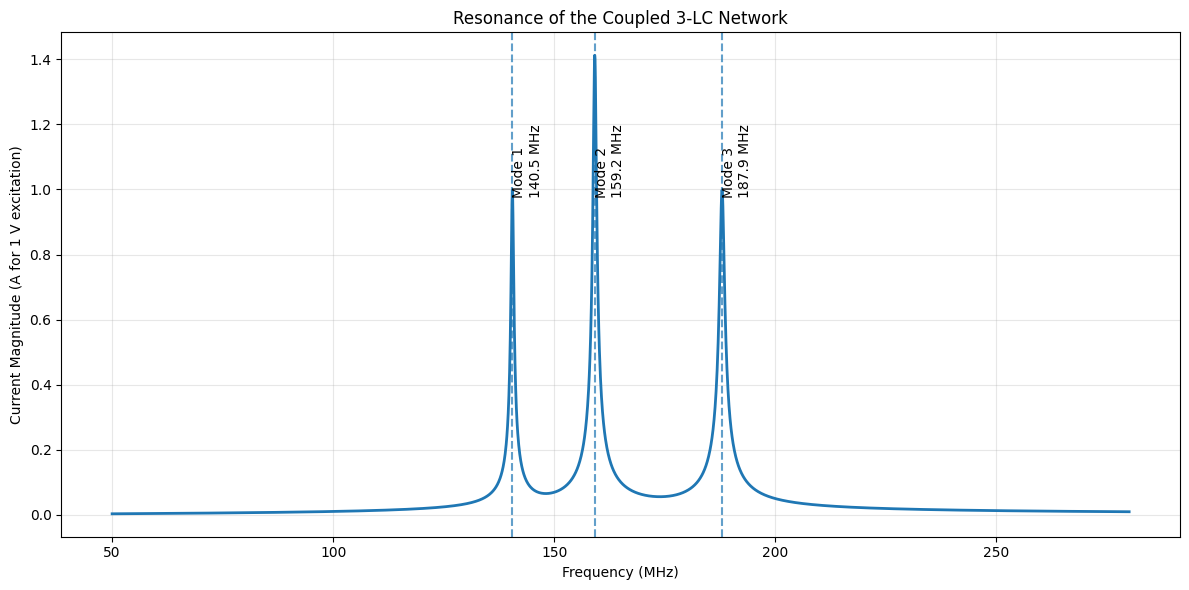

In [ ]:
# ============================================================
# CELL 11: RESONANCE PLOT
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    frequencies / 1e6,
    current_magnitude,
    linewidth=2
)

# Mark the theoretical natural frequencies
for k, f in enumerate(frequency_hz):

    if f_min <= f <= f_max:

        plt.axvline(
            f / 1e6,
            linestyle="--",
            alpha=0.7
        )

        plt.text(
            f / 1e6,
            max(current_magnitude) * 0.85,
            f"Mode {k+1}\n{f/1e6:.1f} MHz",
            rotation=90,
            va="top"
        )

plt.xlabel("Frequency (MHz)")
plt.ylabel("Current Magnitude (A for 1 V excitation)")
plt.title("Resonance of the Coupled 3-LC Network")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

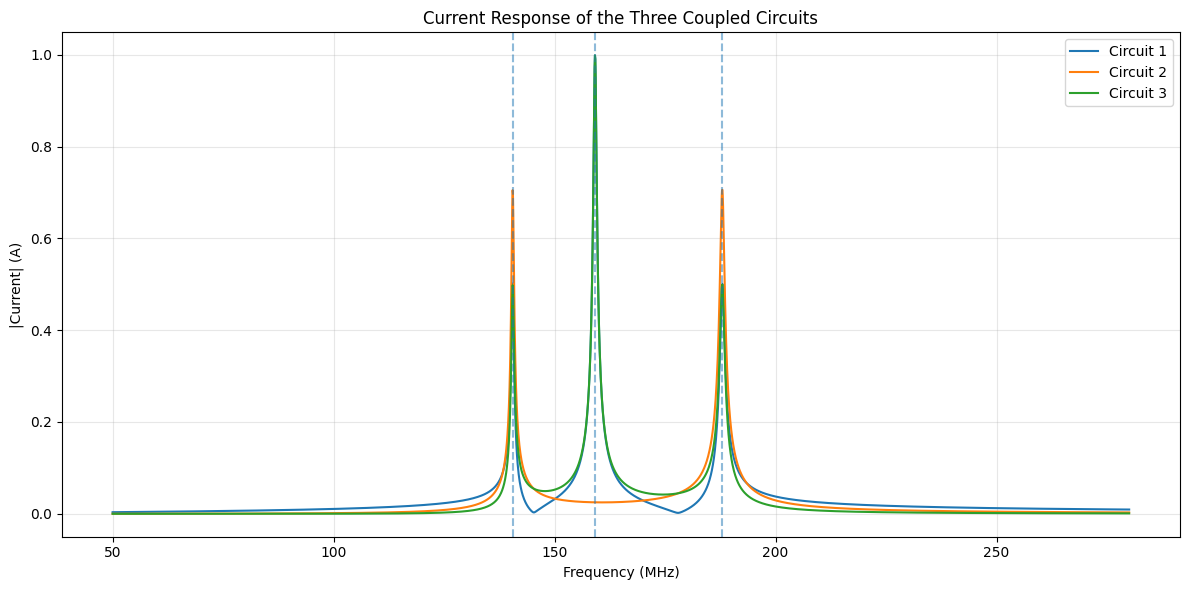

In [ ]:
# ============================================================
# CELL 12: INDIVIDUAL CURRENT RESPONSE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    frequencies / 1e6,
    np.abs(all_currents[0]),
    label="Circuit 1"
)

plt.plot(
    frequencies / 1e6,
    np.abs(all_currents[1]),
    label="Circuit 2"
)

plt.plot(
    frequencies / 1e6,
    np.abs(all_currents[2]),
    label="Circuit 3"
)

for f in frequency_hz:

    if f_min <= f <= f_max:
        plt.axvline(
            f / 1e6,
            linestyle="--",
            alpha=0.5
        )

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Current| (A)")
plt.title("Current Response of the Three Coupled Circuits")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 13: AUTOMATIC RESONANCE SUMMARY
# ============================================================

print("=" * 65)
print("              RESONANCE SUMMARY")
print("=" * 65)

for k, f in enumerate(frequency_hz):

    # Find closest point in frequency sweep
    index = np.argmin(np.abs(frequencies - f))

    print(
        f"Mode {k+1}: "
        f"Natural frequency = {f/1e6:.4f} MHz"
    )

    print(
        f"         Response near resonance = "
        f"{current_magnitude[index]:.6e} A"
    )

    print(
        f"         Eigenvector = "
        f"[{eigenvectors[0,k]:+.3f}, "
        f"{eigenvectors[1,k]:+.3f}, "
        f"{eigenvectors[2,k]:+.3f}]"
    )

    print("-" * 65)

              RESONANCE SUMMARY
Mode 1: Natural frequency = 140.5185 MHz
         Response near resonance = 9.980248e-01 A
         Eigenvector = [+0.707, +1.000, +0.707]
-----------------------------------------------------------------
Mode 2: Natural frequency = 159.1549 MHz
         Response near resonance = 1.412297e+00 A
         Eigenvector = [+1.000, +0.000, -1.000]
-----------------------------------------------------------------
Mode 3: Natural frequency = 187.9373 MHz
         Response near resonance = 9.985880e-01 A
         Eigenvector = [-0.707, +1.000, -0.707]
-----------------------------------------------------------------


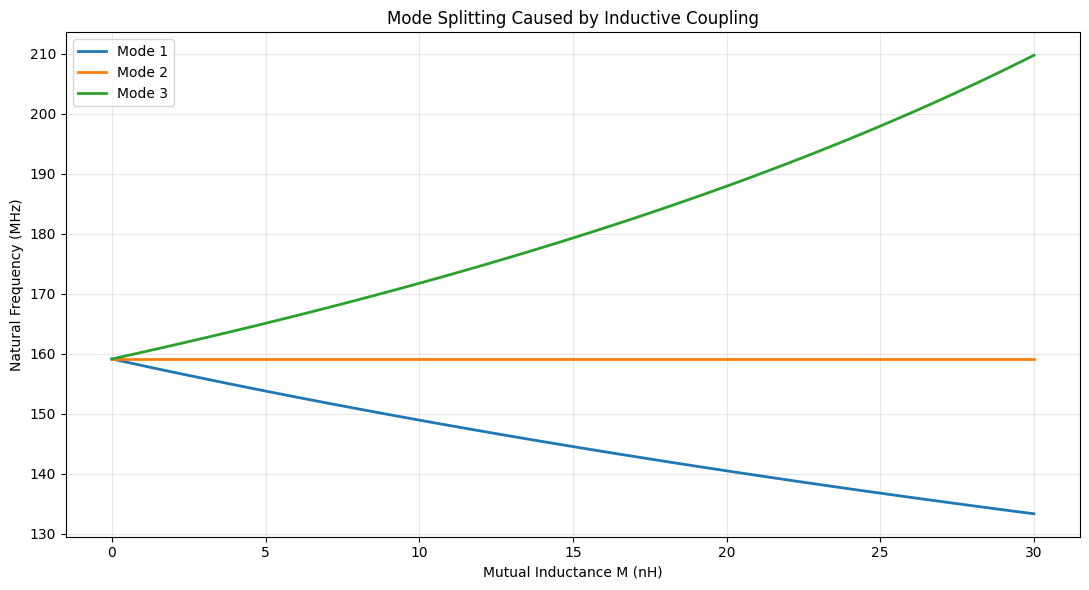

In [ ]:
# ============================================================
# CELL 14: EFFECT OF INDUCTIVE COUPLING
# ============================================================

coupling_values = np.linspace(0, 30e-9, 100)

mode_frequencies = np.zeros((100, 3))

for n, M in enumerate(coupling_values):

    L_test = np.array([
        [L1, M,  0],
        [M,  L2, M],
        [0,  M,  L3]
    ])

    A_test = np.linalg.solve(
        L_test,
        C_inv
    )

    lam_test = np.linalg.eigvals(A_test)

    lam_test = np.sort(
        np.real(lam_test)
    )

    w_test = np.sqrt(lam_test)

    mode_frequencies[n, :] = (
        w_test / (2 * np.pi)
    )

plt.figure(figsize=(11, 6))

for k in range(3):

    plt.plot(
        coupling_values / 1e-9,
        mode_frequencies[:, k] / 1e6,
        linewidth=2,
        label=f"Mode {k+1}"
    )

plt.xlabel("Mutual Inductance M (nH)")
plt.ylabel("Natural Frequency (MHz)")

plt.title(
    "Mode Splitting Caused by Inductive Coupling"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 15: FINAL PROJECT SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("        ELECTRICAL NETWORK NATURAL MODES — FINAL RESULT")
print("=" * 75)

print("\nMATHEMATICAL MODEL")
print("------------------")
print("L i'' + C⁻¹ i = 0")

print("\nEigenvalue problem")
print("------------------")
print("C⁻¹ v = λ L v")
print("λ = ω²")
print("f = sqrt(λ) / (2π)")

print("\nNATURAL FREQUENCIES")
print("-------------------")

for k in range(3):
    print(
        f"Mode {k+1}: "
        f"{frequency_hz[k]/1e6:.4f} MHz"
    )

print("\nEIGENVECTORS")
print("------------")

for k in range(3):
    print(
        f"Mode {k+1}: "
        f"[{eigenvectors[0,k]:+.4f}, "
        f"{eigenvectors[1,k]:+.4f}, "
        f"{eigenvectors[2,k]:+.4f}]"
    )

print("\nINTERPRETATION")
print("--------------")
print(
    "Each eigenvalue gives a natural frequency of the coupled network."
)

print(
    "Each eigenvector gives the relative current distribution "
    "between the three resonators."
)

print(
    "Near a natural frequency, the forced response shows a "
    "resonance peak. Resistance limits the peak amplitude."
)

print("\nProject calculation completed successfully.")
print("=" * 75)



        ELECTRICAL NETWORK NATURAL MODES — FINAL RESULT

MATHEMATICAL MODEL
------------------
L i'' + C⁻¹ i = 0

Eigenvalue problem
------------------
C⁻¹ v = λ L v
λ = ω²
f = sqrt(λ) / (2π)

NATURAL FREQUENCIES
-------------------
Mode 1: 140.5185 MHz
Mode 2: 159.1549 MHz
Mode 3: 187.9373 MHz

EIGENVECTORS
------------
Mode 1: [+0.7071, +1.0000, +0.7071]
Mode 2: [+1.0000, +0.0000, -1.0000]
Mode 3: [-0.7071, +1.0000, -0.7071]

INTERPRETATION
--------------
Each eigenvalue gives a natural frequency of the coupled network.
Each eigenvector gives the relative current distribution between the three resonators.
Near a natural frequency, the forced response shows a resonance peak. Resistance limits the peak amplitude.

Project calculation completed successfully.


In [ ]:

# ============================================================
# COUPLING COMPARISON
# Compare: Without Coupling vs With Coupling
# ============================================================

def calculate_natural_frequencies(L_values, C_values, M12, M13, M23):
    """
    Calculate natural frequencies of the 3 coupled LC circuits.

    Eigenvalue equation:
        L^-1 C^-1 u = w^2 u

    Eigenvalues = w^2
    """

    L1, L2, L3 = L_values
    C1, C2, C3 = C_values

    # Inductance matrix
    L = np.array([
        [L1,  M12, M13],
        [M12, L2,  M23],
        [M13, M23, L3]
    ], dtype=float)

    # Capacitance matrix
    C = np.diag([C1, C2, C3])

    # C^-1
    C_inv = np.linalg.inv(C)

    # Eigenvalue matrix
    A = np.linalg.solve(L, C_inv)

    # Eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(A)

    eigenvalues = np.real(eigenvalues)

    # Natural angular frequencies
    omega = np.sqrt(eigenvalues)

    # Hz
    frequency = omega / (2 * np.pi)

    # Sort
    frequency = np.sort(frequency)

    return frequency


# ------------------------------------------------------------
# Circuit parameters
# ------------------------------------------------------------

L_values = [L1, L2, L3]
C_values = [C1, C2, C3]


# ------------------------------------------------------------
# CASE 1: WITHOUT COUPLING
# M12 = M13 = M23 = 0
# ------------------------------------------------------------

frequency_without = calculate_natural_frequencies(
    L_values,
    C_values,
    0,
    0,
    0
)


# ------------------------------------------------------------
# CASE 2: WITH COUPLING
# Use the mutual inductances from our project
# ------------------------------------------------------------

frequency_with = calculate_natural_frequencies(
    L_values,
    C_values,
    M12,
    M13,
    M23
)


print("Coupling comparison calculation completed.")

Coupling comparison calculation completed.


In [ ]:
# ============================================================
# ENERGY DISTRIBUTION OF EACH NATURAL MODE
# ============================================================

# For a natural mode, the eigenvector gives the relative
# current distribution:
#
#       u = [i1, i2, i3]
#
# Since the magnetic energy depends on current, we use:
#
#       E_i ∝ L_i * |i_i|²
#
# This gives the relative magnetic-energy contribution
# of each individual inductor.
#
# IMPORTANT:
# This is a relative visualization of energy participation,
# not the complete coupled-inductor energy calculation.

energy = np.zeros((3, 3))

for mode in range(3):

    # Current distribution of this mode
    current = eigenvectors[:, mode]

    # Relative energy contribution
    energy[:, mode] = (
        np.array([L1, L2, L3]) *
        np.abs(current)**2
    )

    # Convert to percentage